RANSAC Slope (m): 0.0067
Question 11 - Estimated Crop Field Angle (RANSAC): 0.38 degrees


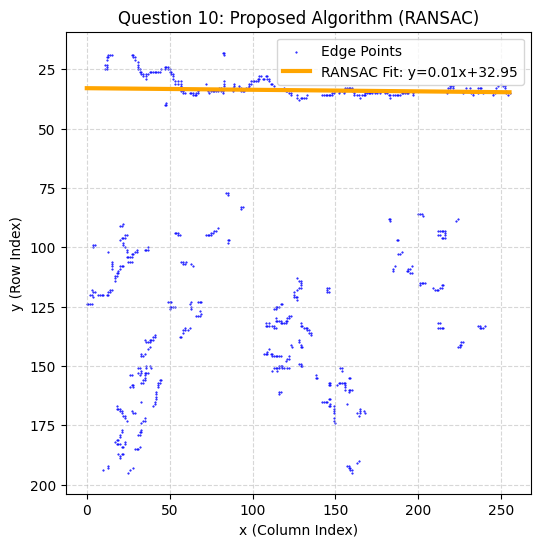

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load Image and Extract Coordinates ---
filename = 'Image of the crop field.png'
img = cv.imread(filename, cv.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not find '{filename}'.")
else:
    edges = cv.Canny(img, 550, 690)
    indices = np.where(edges != 0)
    x = indices[1]
    y = indices[0]

    # --- 2. Proposed Algorithm: Custom RANSAC ---
    def custom_ransac_line_fit(x, y, iterations=2000, threshold=5.0):
        best_m = 0
        best_c = 0
        best_inlier_count = 0
        best_inliers_idx = []
        n_points = len(x)
        
        for _ in range(iterations):
            # Pick 2 random points
            idx = np.random.choice(n_points, 2, replace=False)
            x1, y1 = x[idx[0]], y[idx[0]]
            x2, y2 = x[idx[1]], y[idx[1]]
            
            if x1 == x2: # Avoid division by zero
                continue
                
            # Calculate line equation: y = mx + c
            m = (y2 - y1) / (x2 - x1)
            c = y1 - m * x1
            
            # Calculate perpendicular distance from all points to this line
            distances = np.abs(m * x - y + c) / np.sqrt(m**2 + 1)
            
            # Count inliers
            inliers_idx = np.where(distances < threshold)[0]
            inlier_count = len(inliers_idx)
            
            # Save the best line
            if inlier_count > best_inlier_count:
                best_inlier_count = inlier_count
                best_inliers_idx = inliers_idx
                
        # Refine the final line using only the best inliers
        if len(best_inliers_idx) > 0:
            inlier_x = x[best_inliers_idx]
            inlier_y = y[best_inliers_idx]
            best_m, best_c = np.polyfit(inlier_x, inlier_y, 1)
            
        return best_m, best_c

    # Run the custom RANSAC algorithm
    m_ransac, c_ransac = custom_ransac_line_fit(x, y, iterations=2000, threshold=3.0)
    
    # Calculate the angle of the line in degrees (for Question 11)
    angle_ransac = np.degrees(np.arctan(m_ransac))

    # --- Print Outputs ---
    print(f"RANSAC Slope (m): {m_ransac:.4f}")
    print(f"Question 11 - Estimated Crop Field Angle (RANSAC): {abs(angle_ransac):.2f} degrees")

    # --- 3. Plotting the RANSAC Line ---
    plt.figure(figsize=(6, 6))
    
    # Plot the original scatter points
    plt.scatter(x, y, s=1, c='blue', marker='.', label='Edge Points')

    # Draw the orange RANSAC line from the minimum X to maximum X
    x_plot = np.array([np.min(x), np.max(x)])
    y_plot = m_ransac * x_plot + c_ransac
    plt.plot(x_plot, y_plot, color='orange', linewidth=3, label=f'RANSAC Fit: y={m_ransac:.2f}x+{c_ransac:.2f}')

    plt.gca().invert_yaxis() # Invert Y-axis for image coordinates
    
    plt.title('Question 10: Proposed Algorithm (RANSAC)')
    plt.xlabel('x (Column Index)')
    plt.ylabel('y (Row Index)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    
    plt.show()